<a href="https://colab.research.google.com/github/onietosi/deep-learning-with-python-notebooks/blob/master/5.2-using-convnets-with-small-datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 15. 작은 데이터셋에서의 CNN 훈련

[Note] 이 노트북은 [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python?a_aid=keras&a_bid=76564dff)의 제5장 2절의 내용을 일부 수정하여 작성한 것이다.

----

## 작은 데이터셋에서 convnet을 처음부터 훈련하기

매우 적은 데이터만으로 이미지 분류 모델을 학습해야 하는 상황은 흔히 있는 일이며, 전문적인 맥락에서 컴퓨터 비전을 다루는 사람이라면 실제로 겪어보았을 법한 상황이다.

"적은" 샘플 수는 수백 개에서 수만 개까지 다양할 수 있다. 
실제 예시로, 4,000장의 고양이와 개 사진(고양이 2,000장, 개 2,000장)이 포함된 데이터세트에서 이미지를 "개" 또는 "고양이"로 분류하는 데 집중해 보겠다. 2,000장의 사진은 학습에, 1,000장은 검증에, 마지막으로 1,000장은 테스트에 사용한다.

작은 데이터셋 문제를 해결하기 위한 전략:

* 규제 없이 2,000개의 학습 샘플로 작은 convnet으로 학습 --> 71% 정확도(그러나 과적합 발생)
* 데이터를 증강하고 드롭아웃층이 추가된 convnet으로 학습 --> 82%의 정확도 달성

## 데이터셋 다운로드

* 다운로드 링크: [dogs-vs-cats 데이터셋](www.kaggle.com/c/dogs-vs-cats/data)
* 사진들은 중간 정도의 해상도를 갖는 칼라 JPEG 이다. 사진 샘플:
![cats_vs_dogs_samples](https://s3.amazonaws.com/book.keras.io/img/ch5/cats_vs_dogs_samples.jpg)

- 다운로드된 파일은 현재 이 주피터 노트북 파일 `15_1_using_convnets_with_small_datasets.ipynb`와 동일한 폴더에 있어야 한다.
- 다운로드된 데이터셋 'dogs-vs-cats.zip' ==> 'dogs-vs-cats에 압축풀기'로 압축을 푼다.
- dogs-vs-cats 폴더로 이동하여 'test1.zip', 'train.zip', 'sampleSubmission.csv' 이 있는지 확인한다.
- 'test1.zip'과 'train.zip'을 'test1' 폴더와 'train' 폴더에 압축해제한다.
- 'train' 폴더의 내용: 25,000개의 jpg 파일
- 'test1' 폴더의 내용: 12,500개의 jpg 파일
- 이제 노트북 파일이 있는 위치로 돌아온다.

### 데이터셋 다운로드 및 압축풀기가 완료된 상태:
```
working-directory
└───dogs-vs-cats   
    ├───test1   
    └───train
```

### 다음과 같은 디렉터리 구조가 되도록 train, validation 및 test 데이터셋을 분할하여 구축한다.
```
dogs-vs-cats  
    ├───cats_and_dogs_small   
    │   ├───test  
    │   │   ├───cats  
    │   │   └───dogs  
    │   ├───train  
    │   │   ├───cats  
    │   │   └───dogs  
    │   └───validation  
    │       ├───cats  
    │       └───dogs  
    ├───test1  
    └───train
```

In [1]:
import sys
import os, shutil

# 원래 데이터셋 중 train 폴더
original_dataset_dir = './dogs-vs-cats/train'

# 작은 데이터셋을 저장할 위치 : 앞으로 데이터셋의 시작 위치가 됨
base_dir = './dogs-vs-cats/cats_and_dogs_small'
os.mkdir(base_dir)

# training, validation 및 test 데이터셋을 분할 저장할 위치
train_dir = os.path.join(base_dir, 'train')
os.mkdir(train_dir)
validation_dir = os.path.join(base_dir, 'validation')
os.mkdir(validation_dir)
test_dir = os.path.join(base_dir, 'test')
os.mkdir(test_dir)

# cat 훈련 데이터
train_cats_dir = os.path.join(train_dir, 'cats')
os.mkdir(train_cats_dir)

# dog 훈련 데터터
train_dogs_dir = os.path.join(train_dir, 'dogs')
os.mkdir(train_dogs_dir)

# cat 검증 데이터
validation_cats_dir = os.path.join(validation_dir, 'cats')
os.mkdir(validation_cats_dir)

# dog 검증 데터터
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
os.mkdir(validation_dogs_dir)

# cat 테스트 데이터
test_cats_dir = os.path.join(test_dir, 'cats')
os.mkdir(test_cats_dir)

# dog 테스트 데이터
test_dogs_dir = os.path.join(test_dir, 'dogs')
os.mkdir(test_dogs_dir)

# cat 이미지 중에서 처음 1,000개를 train_cats_dir로 copy
fnames = ['cat.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_cats_dir, fname)
    shutil.copyfile(src, dst)

# 다음 500개의 cat 이미지를 validation_cats_dir로 copy
fnames = ['cat.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_cats_dir, fname)
    shutil.copyfile(src, dst)

# 다음 500개의 cat 이미지를 test_cats_dir로 copy
fnames = ['cat.{}.jpg'.format(i) for i in range(1500, 2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_cats_dir, fname)
    shutil.copyfile(src, dst)

# Copies the first 1,000 dog images to train_dogs_dir
# dog 이미지 중에서 처음 1,000개를 train_dogs_dir로 copy
fnames = ['dog.{}.jpg'.format(i) for i in range(1000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_dogs_dir, fname)
    shutil.copyfile(src, dst)

# 다음 500개의 dog 이미지를 validation_dogs_dir로 copy
fnames = ['dog.{}.jpg'.format(i) for i in range(1000, 1500)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_dogs_dir, fname)
    shutil.copyfile(src, dst)

# Copies the next 500 dog images to test_dogs_dir
# 다음 500개의 d 이미지를 test_dogs_dir로 copy
fnames = ['dog.{}.jpg'.format(i) for i in range(1500, 2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(test_dogs_dir, fname)
    shutil.copyfile(src, dst)

### 데이터셋 준비가 잘 되었는지 확인하기 위해 각 데이터셋의 수를 세어보자.

In [2]:
print('total training cat images:', len(os.listdir(train_cats_dir)))

total training cat images: 1000


In [3]:
print('total training dog images:', len(os.listdir(train_dogs_dir)))

total training dog images: 1000


In [4]:
print('total validation cat images:', len(os.listdir(validation_cats_dir)))

total validation cat images: 500


In [5]:
print('total validation dog images:', len(os.listdir(validation_dogs_dir)))

total validation dog images: 500


In [6]:
print('total test cat images:', len(os.listdir(test_cats_dir)))

total test cat images: 500


In [7]:
print('total test dog images:', len(os.listdir(test_dogs_dir)))

total test dog images: 500


#### 분할 결과 확인:
- 훈련   이미지: 2000개
- 검증   이미지: 1000개
- 테스트 이미지: 1000개
- 각 데이터 분할에는 cat 이미지와 dog 이미지가 동일한 수 만큼씩 들어있다(클래스간 샘플 수가 균형이 잡혀있다). 따라서 분류 정확도(Accuracy)를 적절한 성공 측도로 사용할 수 있다.

### CNN 설계 방향
- Fashio-MNIST와 같이 Conv2D 층과 MaxPooling 층을 사용한 일반적인 구조를 사용할 것이다.
- 그러나, 이미지가 더 크고 복잡하므로 신경망의 크기를 키울 것이다. 즉,
  - Conv2D + MaxPooling2D 블록을 하나 더 추가.
  - 이는 네트워크 용량을 늘리는 동시에 특징 맵의 크기를 줄여 Flatten 층에 도달했을 때 특징 맵이 지나치게 커지지 않도록 한다.
  - 여기서는 150x150 크기의 입력에서 시작하기 때문에, Flatten 층 바로 앞에 7x7 크기의 특징 맵이 생성된다.    
- 네트워크에서 특징 맵의 깊이는 32에서 128로 점차 증가하는 반면, 특징 맵의 크기는 148x148에서 7x7로 감소하는 것을 확인할 수 있다. 이는 거의 모든 합성곱 신경망에서 볼 수 있는 패턴이다.
- Fashion-MNIST에서와는 다르게 Dropout 층은 사용하지 않았다.
- 이진 분류 문제를 다루기 때문에, 단일 유닛(크기 1의 Dense 계층)과 시그모이드 활성화 함수로 네트워크를 마무리한다. 이 유닛은 네트워크가 두 클래스 중 하나를 선택할 확률을 인코딩한다.

### 재현성을 위한 random seed 설정

In [8]:
import os
import numpy as np
import tensorflow as tf
import random

# 텐서플로우를 포함한 모델을 실행할 때마다 동일한 결과를 얻기 위한 재현성 설정 함수.
# 같은 코드로 여러 모델을 만드는 경우 각 모델이 만들어지기 전에 다시 실행해야 함.
def set_random_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = "1"
    os.environ['TF_CUDNN_DETERMINISM'] = "1"  # 최신 TF에서는 위의 것으로 대체 가능
    os.environ['PYTHONHASHSEED'] = str(seed)

set_random_seed(seed=42)

### CNN 모델 구축

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),  # Input 층 추가
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [10]:
# 모델 요약 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

- Fashion-MNIST에서와는 다르게 옵티마이저를 학습률 0.0001로 RMSprop을 사용하기로 한다.
- 손실함수는 이진 분류이므로, 'binary_crossentropy'를 사용한다.

In [11]:
# 모델 컴파일
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

### 데이터 전처리(Data preprocessing)
신경망에 입력하기 전에, 적절히 전처리하여 부동소숫점(floating point) 텐서로 포맷되어야 한다.

* 이미지 파일을 읽기
* JPEG 콘텐츠를 RGB 픽셀 그리드로 디코딩
* floafing point tensor로 변환
* 픽셀값(0~255)을 [0, 1] 구간값으로 조절
  



#### 파이썬 코딩으로 처리하기에는 어려워 보이는가?
* 텐서플로우 케라스의 이미지 처리 helper 도구가 포함된 `tf.keras.preprocessing.image` 모듈을 사용하자.
* `tf.keras.preprocessing.image.ImageDataGenerator` 클래스: 디스크에 있는 이미지 파일을 전처리된 텐서 Batch로 자동 변환하는 Python 생성기를 빠르게 설정할 수 있게 해준다

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 이미지 크기를 1./255 로 조정한다.
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        # target directory
        train_dir,
        # 모든 이미지 크기를 150x150 으로 조정 
        target_size=(150, 150),
        batch_size=20,
        # binary_crossentropy 손실함수를 사용하므로 이진 레이블이 필요하다.
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


### [STUDY] 파이썬 generator 이해하기
* 파이썬 generator는 iterator로 동작하는 객체: `for ... in` 연산자와 함께 사용할 수 있는 객체다.
* generator는 `yield` 연산자를 사용하여 만들어진다.

In [13]:
def generator():
    i = 0
    while True:
        i += 1
        yield i

for item in generator():
    print(item)
    if item > 4:
        break

1
2
3
4
5


[STUDY 끝]

#### generator 중 하나의 출력을 살펴보자.
* 150x150 RGB 이미지(shape=(20, 150, 150, 3))와 이진 레이블(shape=(20,))로 구성된 batch를 생성한다.
* 여기서, 20은 batch_size
* generator는 이러한 배치를 무한히 생성한다. 즉, 대상 폴더에 있는 이미지들을 무한히 반복한다. 따라서 어느 시점에서 반복 루프를 끊어야 한다.

In [14]:
for data_batch, labels_batch in train_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break

data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)


### Batch generator를 사용하여 모델을 데이터에 적합(fitting)시키기
* 파이썬 생성기인 train_generator를 사용하므로 과거 버전에서는 fit_generator 메서드를 사용하여 적합시켰지만 지금은 `fit`으로 통일됐다.
* 훈련 샘플 수가 2000개, batch_size=20 이므로 steps_per_epoch=100
* 30 에포크 동안 훈련한다
* validation_data로 validation_generator를 전달하려면, validation_generator에서 평가를 위해 몇 개의 배치를 가져올지 프로세스에 알려주는 validation_steps 인수도 지정해야 한다.

In [15]:
history = model.fit(
      train_generator,
      steps_per_epoch=100,
      epochs=30,
      validation_data=validation_generator,
      validation_steps=50)

Epoch 1/30


C:\Users\kikim\anaconda3\envs\handson3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 301ms/step - accuracy: 0.5159 - loss: 0.6911 - val_accuracy: 0.5200 - val_loss: 0.6917
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.5756 - loss: 0.6765 - val_accuracy: 0.5970 - val_loss: 0.6648
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.6013 - loss: 0.6552 - val_accuracy: 0.6150 - val_loss: 0.6537
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - accuracy: 0.6485 - loss: 0.6274 - val_accuracy: 0.6290 - val_loss: 0.6323
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.6481 - loss: 0.6105 - val_accuracy: 0.6480 - val_loss: 0.6093
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.6977 - loss: 0.5712 - val_accuracy: 0.6680 - val_loss: 0.6103
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - accuracy: 0.7035 - loss: 0.5612 - val_accuracy: 0.6620 - val_loss: 0.6121
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.7163 - loss: 0.5344 - val

훈련 후에는 항상 모델을 저장하는 것이 좋다: 

In [16]:
model.save('cats_and_dogs_small_1.keras')

훈련 및 검증 데이터에 대한 손실 및 정확도 그래프를 그려보자:

In [17]:
len(history.history['accuracy'])

30

In [18]:
history.history

{'accuracy': [0.5254999995231628,
  0.5799999833106995,
  0.6184999942779541,
  0.6585000157356262,
  0.6589999794960022,
  0.6959999799728394,
  0.7120000123977661,
  0.722000002861023,
  0.7455000281333923,
  0.75,
  0.7680000066757202,
  0.7860000133514404,
  0.7900000214576721,
  0.8100000023841858,
  0.8144999742507935,
  0.8240000009536743,
  0.8345000147819519,
  0.8514999747276306,
  0.8535000085830688,
  0.8650000095367432,
  0.878000020980835,
  0.8845000267028809,
  0.8949999809265137,
  0.8980000019073486,
  0.9125000238418579,
  0.9154999852180481,
  0.9300000071525574,
  0.9340000152587891,
  0.9415000081062317,
  0.9465000033378601],
 'loss': [0.6888452172279358,
  0.674249529838562,
  0.6510066986083984,
  0.6250725984573364,
  0.6030709147453308,
  0.5728853940963745,
  0.5538374185562134,
  0.5337201356887817,
  0.5114660263061523,
  0.5037875175476074,
  0.4772517681121826,
  0.46064090728759766,
  0.4448649287223816,
  0.41980504989624023,
  0.4070744216442108,
  0.

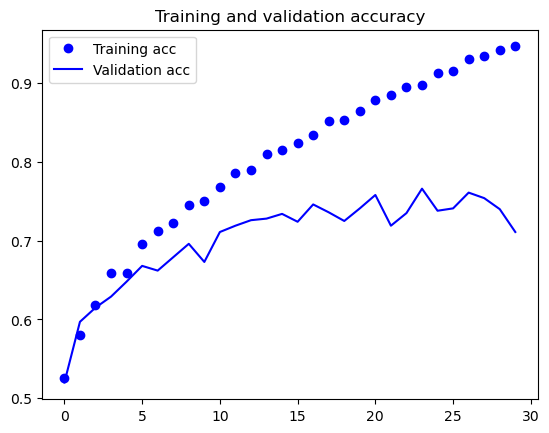

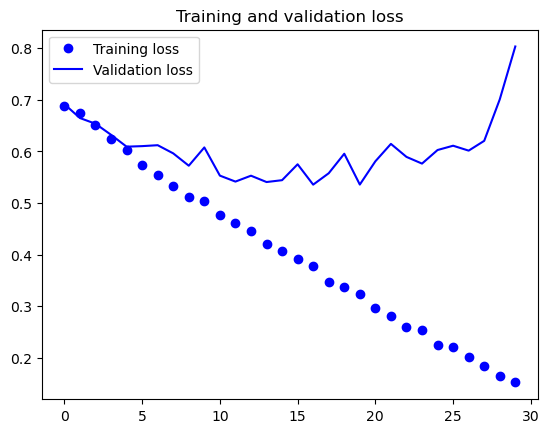

In [19]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

## * 그래프는 과적합의 특징을 보인다. 훈련 정확도는 선형적으로 증가하여 거의 100%에 도달하는 반면, 검증 정확도는 72~75%에서 정체
* 검증 손실은 10~12 epoch만에 최소값에 도달한 후 정체되다가 20 epoch 이후 급격히 증가하고
* 훈련 손실은 거의 0에 도달할 때까지 선형적으로 계속 감소
* 과적합의 원인 중 가장 큰 것은 아마도 훈련 샘플(2000개)이 적은 것일 것이다.
* 과적합 방지를 위한 규제(Regularization) 방법을 도입하기 전에 우선 훈련 샘플을 늘리기 위해 `데이터 증강(Data Augmentation)`을 수행한다.

## 데이터 증강 사용하기
* 데이터 증강의 목표는 학습 시점에 모델이 정확히 동일한 사진을 두 번 보지 않도록 하는 것이다.
* `ImageDataGenerator`를 사용하여 읽은 이미지에 대한 여러가지 무작위 변환을 수행하여 데이터를 증강한다.

#### 데이터 증강의 예:

In [20]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

`ImageDataGenerator` 옵션:
- rotation_range: 무작위 회전 범위(0~180도)
- width_shift, height_shift: 수평 또는 수직 이동할 범위(전체 너비 또는 높이의 비율)
- shear_range: 무작위로 전단 변환(예: 직사각형의 옆을 밀어서 평행사변형이되게 하는 것)
- zoom_range: 무작위로 확대/축소
- horizontal_flip: 이미지의 절반을 무작위로 수평으로 뒤집는 것(수평 비대칭성이 가정되지 않은 경우(예: 실제 사진)에 유용)
- fill_mode: 회전 또는 너비/높이 이동 후 나타날 수 있는 새로 생성된 픽셀을 채우는 데 사용되는 전략
  - 'nearest'(기본): 가장 가까운 기존 픽셀 값을 사용하여 빈 공간을 채움(가장자리가 계단처럼 보이거나 픽셀화되는 현상이 종종 발생)
  - 'reflect': 이미지 내용이 경계를 넘어 반사되어 빈 공간을 채움(거울 효과)
  - 'wrap': 이미지 반대편의 픽셀을 사용하여 빈 공간을 채움 
  - 'constant': 새로 생성된 영역을 검정(0)이나 흰색(255) 등과 같은 특정 색상이나 강도로 채울 수 있다.

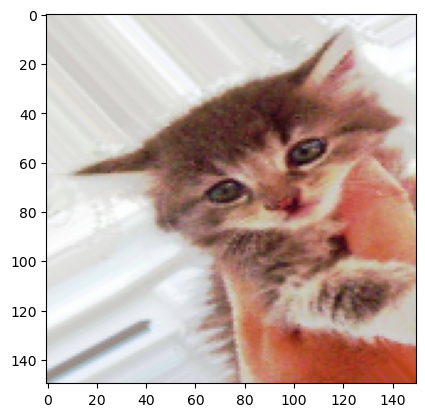

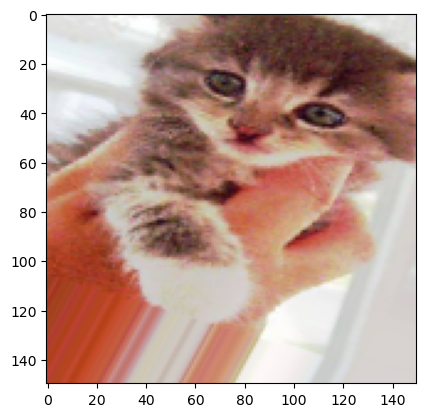

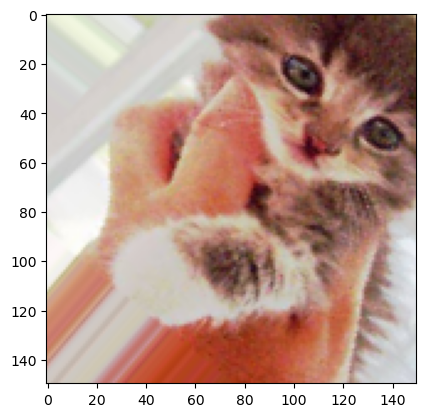

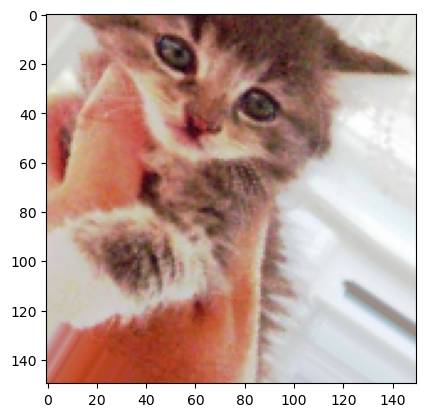

In [21]:
# 이미지 전처리 유틸리티가 있는 모듈
from keras.preprocessing import image

fnames = [os.path.join(train_cats_dir, fname) for fname in os.listdir(train_cats_dir)]

# 증강시킬 이미지 한 개를 선택
img_path = fnames[3]

# 이미지 읽고 크기를 변경
img = image.load_img(img_path, target_size=(150, 150))

# shape=(150, 150, 3)의 Numpy array로 변환
x = image.img_to_array(img)

# shape=(1, 150, 150, 3)가 되도록 Reshape
x = x.reshape((1,) + x.shape)

# .flow() 명령은 무작위로 변환된 이미지의 batch를 생성함
# 뱃치가 무한히 생성되므로, 적정 조건에서 정지시켜야 한다.
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 4 == 0:
        break

plt.show()

- 증강된 데이터를 사용하면 모델이 학습 중 동일한 입력을 두 번 받는 일이 없게 된다.
- 그러나, 원본 이미지를 변형한 것이므로 여전히 이미지들 간에 높은 상관관계를 갖는다.
- 따라서, 더 효과적으로 과적합을 방지하기 위해 Dense층 앞에서 Dropout층을 추가한다.

In [ ]:
set_random_seed(seed=42)

In [22]:
# Dropout층이 추가된 모델
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),  # Input 층 추가
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 모델 컴파일
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

#### Dropout이 추가된 모델을 증강된 데이터로 다시 훈련하자.
**[주의]** 검증 데이터는 증강하면 안된다!

In [23]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,)

# [주의] 검증 데이터는 증강하면 안된다!
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        # target directory
        train_dir,
        # 모든 이미지 크기를 150x150 으로 조정
        target_size=(150, 150),
        batch_size=32,
        # binary_crossentropy 손실함수를 사용하므로 이진 레이블이 필요하다.
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')

history = model.fit(
      train_generator,
      steps_per_epoch=100,
      epochs=100,
      validation_data=validation_generator,
      validation_steps=50)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/100
 63/100 ━━━━━━━━━━━━━━━━━━━━ 13s 364ms/step - accuracy: 0.5017 - loss: 0.6959

C:\Users\kikim\anaconda3\envs\handson3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 267ms/step - accuracy: 0.5066 - loss: 0.6954 - val_accuracy: 0.5550 - val_loss: 0.6907
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 264ms/step - accuracy: 0.5092 - loss: 0.6931 - val_accuracy: 0.5630 - val_loss: 0.6878
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 265ms/step - accuracy: 0.5279 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6990
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 267ms/step - accuracy: 0.5413 - loss: 0.6869 - val_accuracy: 0.5920 - val_loss: 0.6705
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 266ms/step - accuracy: 0.5630 - loss: 0.6764 - val_accuracy: 0.5880 - val_loss: 0.6690
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 266ms/step - accuracy: 0.5754 - loss: 0.6745 - val_accuracy: 0.5490 - val_loss: 0.6737
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 268ms/step - accuracy: 0.5848 - loss: 0.6683 - val_accuracy: 0.5890 - val_loss: 0.6625
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 266ms/step - accuracy: 0.6234 - loss: 0.656

convnet 시각화에 사용하기 위해 모델을 저장해둔다.

In [24]:
model.save('cats_and_dogs_small_2.keras')

그래프로 다시 확인해보자.

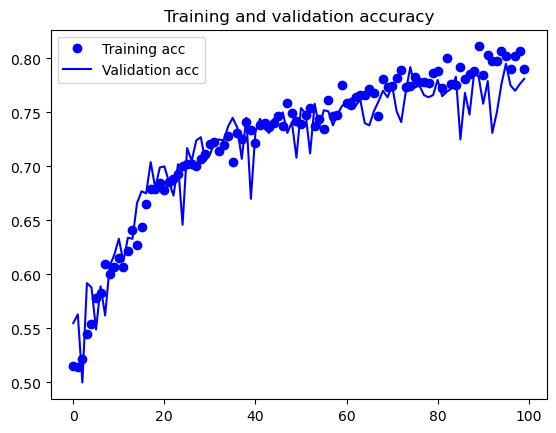

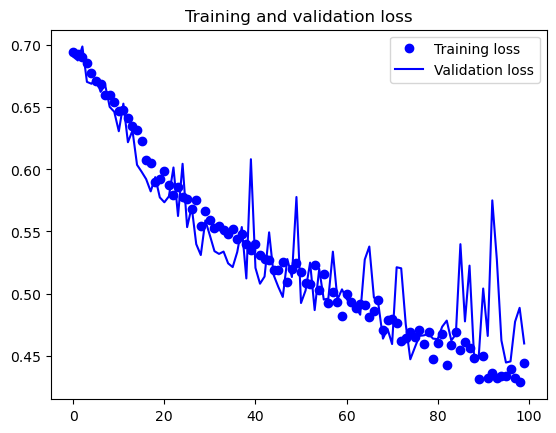

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

## 결론
* 데이터 증가와 드롭아웃 덕분에 더 이상 과적합 현상이 발생하지 않는다.
* 훈련 곡선이 검증 곡선을 거의 정확하게 따라가고 있으며, 이제 82%의 정확도를 달성할 수 있다(규제되지 않은 모델보다 15% 향상된 수치)
* 규제 기법을 더욱 활용하고 네트워크 하이퍼파라미터(예: 합성곱 층당 필터 수 또는 네트워크 층 수)를 조정하면 86~87%까지 더 높은 정확도를 얻을 수 있다.
* 그러나, 원래 데이터가 너무 부족하기 때문에 처음부터 자체 합성곱 신경망을 훈련하는 것만으로는 정확도를 더 높이는 것이 매우 어렵다.